## Retail Sales Dataset - Task-1 Exploratory Data Analysis

## Project Objective
The objective of this project is to perform Exploratory Data Analysis (EDA) on retail sales data to identify sales trends, customer demographics, product performance, and other useful business insights.

To analyze retail sales data and identify:
- Sales trends over time
- Customer demographics
- Best-selling products
- Category-wise revenue
- Relationships between numerical variables
- Actionable business insights

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Load & Initial Inspection

In [28]:
df= pd.read_csv('data/retail_sales_data_.csv')

In [29]:
df.head()

,Transaction ID,Customer ID,Age,Gender,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date
0,TXN_6867343,CUST_09,53,Male,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08
1,TXN_3731986,CUST_22,39,Male,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23
2,TXN_9303719,CUST_02,59,Male,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05
3,TXN_9458126,CUST_06,49,Male,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07
4,TXN_4575373,CUST_05,25,Female,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02


In [30]:
df.shape

(12575, 12)

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  str    
 1   Customer ID       12575 non-null  str    
 2   Age               12575 non-null  int64  
 3   Gender            12575 non-null  str    
 4   Category          12575 non-null  str    
 5   Item              11362 non-null  str    
 6   Price Per Unit    11966 non-null  float64
 7   Quantity          11971 non-null  float64
 8   Total Spent       11971 non-null  float64
 9   Payment Method    12575 non-null  str    
 10  Location          12575 non-null  str    
 11  Transaction Date  12575 non-null  str    
dtypes: float64(3), int64(1), str(8)
memory usage: 1.2 MB


In [32]:
df.isnull().sum()

Transaction ID         0
Customer ID            0
Age                    0
Gender                 0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
dtype: int64

In [33]:
df.duplicated().sum()

np.int64(0)

## Descriptive Statistics

In [34]:
stats = pd.DataFrame({
    'Mean': df.mean(numeric_only=True),
    'Median': df.median(numeric_only=True),
    'Mode': df.mode(numeric_only=True).iloc[0],
    'Standard Deviation': df.std(numeric_only=True)})

stats

,Mean,Median,Mode,Standard Deviation
Age,46.868469,49.0,39.0,12.826895
Price Per Unit,23.365912,23.0,33.5,10.743519
Quantity,5.536380,6.0,10.0,2.857883
Total Spent,129.652577,108.5,40.0,94.750697


## Time Series Analysis

## Monthly Sales Trend

In [35]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'],errors='coerce')
df['Transaction Date'].head()

0   2024-04-08
1   2023-07-23
2   2022-10-05
3   2022-05-07
4   2022-10-02
Name: Transaction Date, dtype: datetime64[us]

In [36]:
monthly_sales = df.dropna(subset=['Total Spent']).groupby(df.dropna(subset=['Total Spent'])['Transaction Date'].dt.to_period('M'))['Total Spent'].sum()
monthly_sales

Transaction Date
2022-01    52911.5
2022-02    43325.5
2022-03    40996.0
2022-04    40442.0
2022-05    40347.5
2022-06    42576.0
2022-07    44471.5
2022-08    41333.5
2022-09    46113.5
2022-10    38355.0
2022-11    41256.5
2022-12    38201.0
2023-01    48052.5
2023-02    39214.5
2023-03    38534.5
2023-04    38905.5
2023-05    40480.5
2023-06    42474.0
2023-07    45632.5
2023-08    38592.0
2023-09    41069.0
2023-10    38322.0
2023-11    37014.0
2023-12    43021.0
2024-01    47908.5
2024-02    37145.0
2024-03    42861.5
2024-04    46271.0
2024-05    43766.5
2024-06    44721.0
2024-07    41405.0
2024-08    43362.0
2024-09    42161.5
2024-10    42736.5
2024-11    44076.0
2024-12    48466.5
2025-01    25548.5
Freq: M, Name: Total Spent, dtype: float64

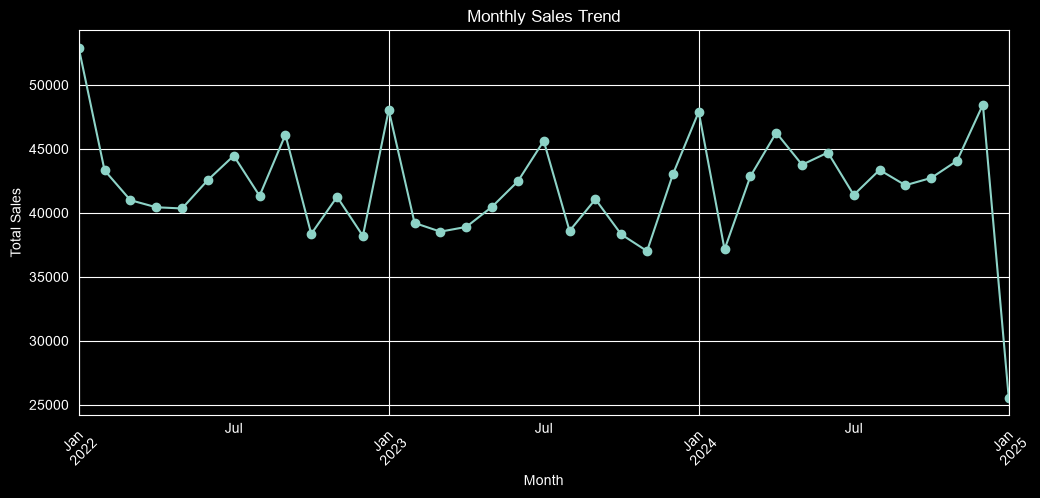

In [37]:
monthly_sales.plot(kind='line',figsize=(12,5),marker ='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

**Observation:** Monthly sales fluctuate throughout the period, with several peaks and declines. Overall, sales remain relatively stable around the 40,000–48,000 range for most months, while January 2022 shows the highest sales and January 2025 shows a noticeable decline.

## Quarterly Sales Trend

In [38]:
quarterly_sales = df.dropna(subset=['Total Spent']).groupby(df.dropna(subset=['Total Spent'])
['Transaction Date'].dt.to_period('Q'))['Total Spent'].sum()

quarterly_sales

Transaction Date
2022Q1    137233.0
2022Q2    123365.5
2022Q3    131918.5
2022Q4    117812.5
2023Q1    125801.5
2023Q2    121860.0
2023Q3    125293.5
2023Q4    118357.0
2024Q1    127915.0
2024Q2    134758.5
2024Q3    126928.5
2024Q4    135279.0
2025Q1     25548.5
Freq: Q-DEC, Name: Total Spent, dtype: float64

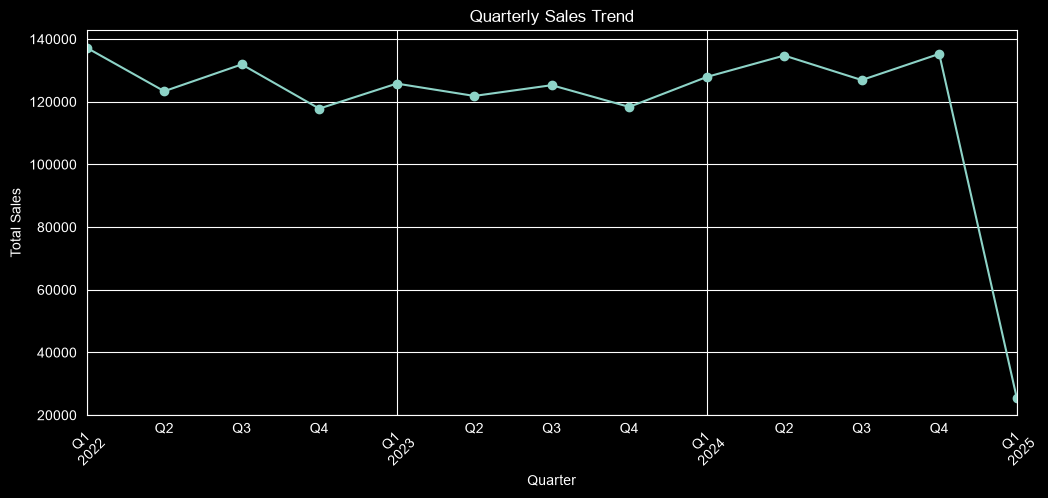

In [39]:
quarterly_sales.plot(kind='line',figsize=(12,5),marker ='o')

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

**Observation:** Quarterly sales remain relatively stable between 2022 and 2024, with some fluctuations across quarters. The highest sales are observed in Q2 2024, while Q1 2025 shows a sharp decline, which may be influenced by the limited data available for that quarter.

## Customer Demographics Analysis

In [40]:
df['Age Group'] = pd.cut(df['Age'],bins= [17,25,35,45,55,70],labels=['18-25','26-35','36-45','46-55','56-70'])

In [41]:
age_groups= df['Age Group'].value_counts().sort_index()
age_groups

Age Group
18-25    1077
26-35    1010
36-45    2972
46-55    3984
56-70    3532
Name: count, dtype: int64

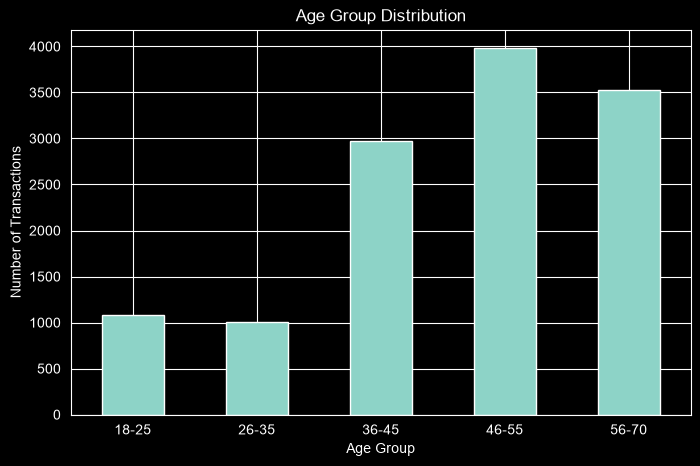

In [42]:
age_groups.plot(kind='bar',figsize=(8,5))

plt.title('Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.show()

**Observation:** The 46-55 age group has the highest number of transactions, followed by the 56-70 age group. The 26-35 age group has the lowest number of transactions, indicating that older customer groups contribute more transactions in this dataset.

In [43]:
gender_counts = df['Gender'].value_counts()
gender_counts

Gender
Male      7984
Female    4591
Name: count, dtype: int64

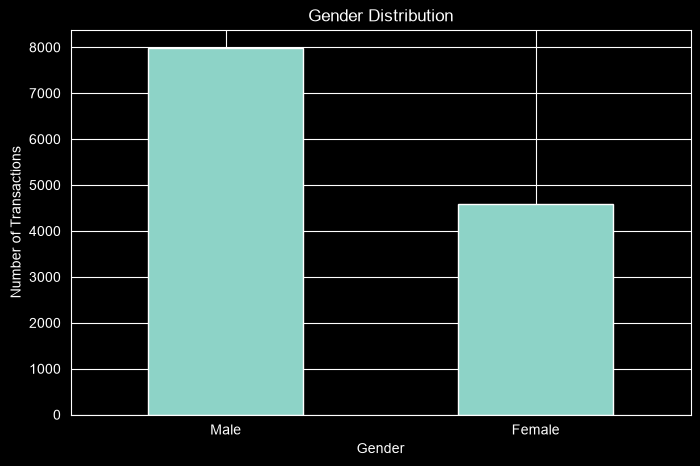

In [44]:
gender_counts.plot(kind='bar',figsize=(8,5))

plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.show()

**Observation:** Male customers account for 7,984 transactions, while female customers account for 4,591 transactions. This shows that male customers contribute a larger share of transactions in the dataset.

### Top 10 Best-Selling Products

In [45]:
top_products = df.groupby('Item')['Quantity'].sum().sort_values(ascending=False).head(10)
top_products

Item
Item_2_BEV      676.0
Item_16_MILK    627.0
Item_25_FUR     616.0
Item_19_MILK    589.0
Item_5_FUR      581.0
Item_13_FOOD    581.0
Item_1_MILK     578.0
Item_11_MILK    574.0
Item_11_FUR     573.0
Item_14_FOOD    566.0
Name: Quantity, dtype: float64

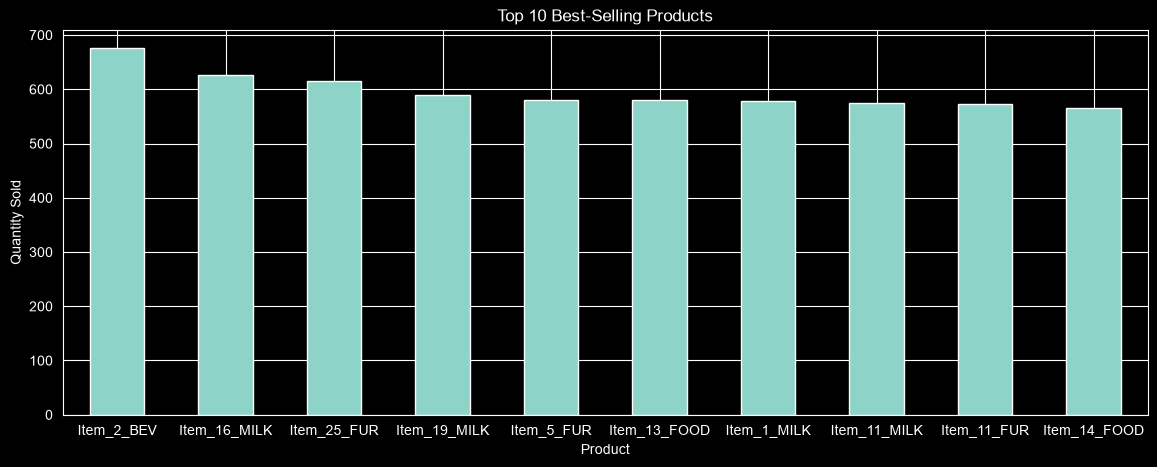

In [46]:
top_products.plot(kind='bar',figsize=(14,5))

plt.title('Top 10 Best-Selling Products')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=0)
plt.show()

**Observation:** Item_2_BEV has the highest quantity sold among the top 10 products, followed by Item_16_MILK and Item_25_FUR. The top-selling products have relatively close sales volumes, indicating that no single product dominates the sales volume significantly.

In [47]:
category_revenue = df.dropna(subset=['Total Spent']).groupby('Category')['Total Spent'].sum().sort_values(ascending=False)
category_revenue

Category
Butchers                              208118.0
Electric household essentials         203813.5
Beverages                             197047.5
Furniture                             195310.0
Food                                  194812.0
Computers and electric accessories    190692.5
Patisserie                            182165.5
Milk Products                         180112.0
Name: Total Spent, dtype: float64

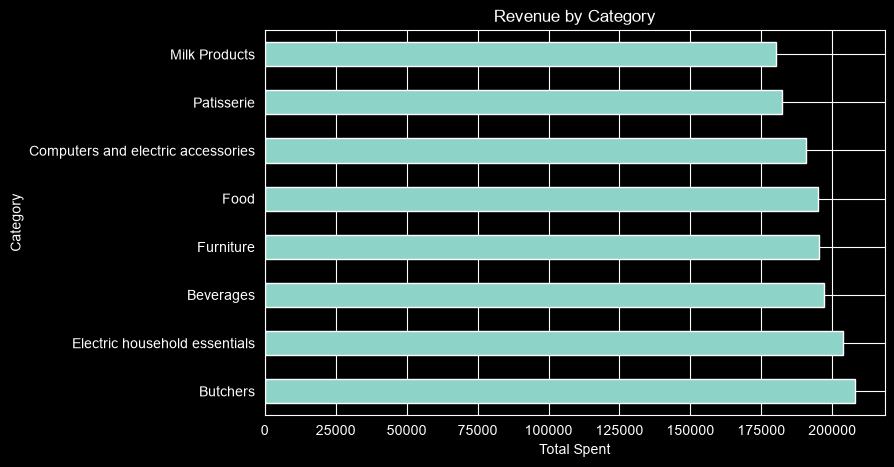

In [48]:
category_revenue.plot(kind='barh',figsize=(8,5))

plt.title('Revenue by Category')
plt.xlabel('Total Spent')
plt.ylabel('Category')

plt.show()

**Observation:** Butchers generates the highest revenue among all categories, followed by Electric household essentials. Milk Products has the lowest revenue. Overall, revenue is fairly distributed across categories, with Butchers showing the strongest contribution.

### Correlation Heatmap

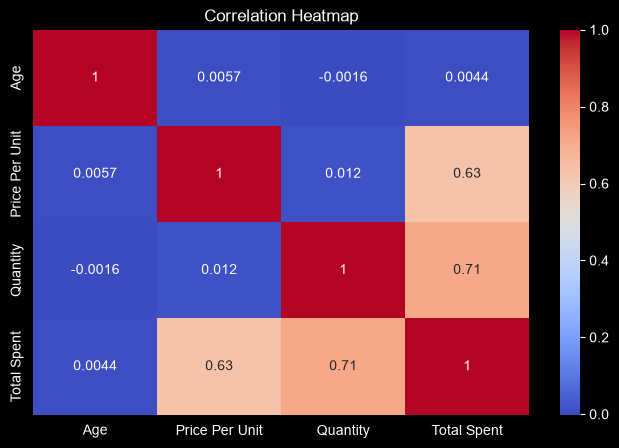

In [49]:
correlation = df[['Age', 'Price Per Unit', 'Quantity', 'Total Spent']].corr()

plt.figure(figsize=(8, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Observation:** Quantity and Total Spent show a strong positive correlation (0.71), indicating that transactions with higher quantities generally have higher total spending. Price Per Unit also has a positive correlation with Total Spent (0.63). Age shows almost no correlation with Total Spent or Quantity.

### Additional Insight: Average Spending by Payment Method

In [50]:
avg_spending = df.dropna(subset=['Total Spent']).groupby('Payment Method')['Total Spent'].mean().sort_values(ascending=False)
avg_spending

Payment Method
Cash              131.052888
Credit Card       129.127069
Digital Wallet    128.718346
Name: Total Spent, dtype: float64

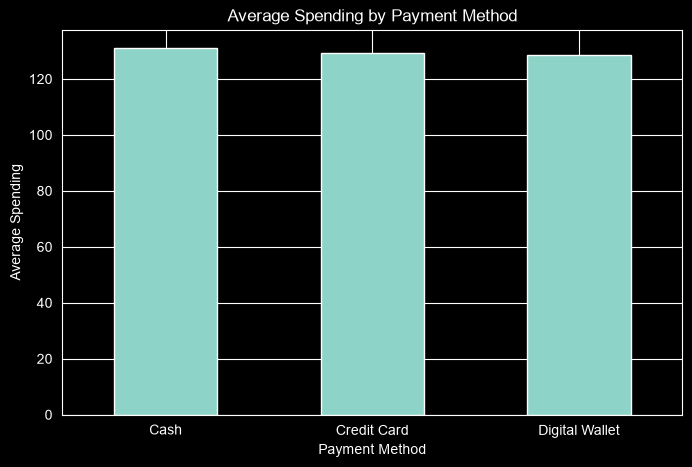

In [51]:
avg_spending.plot(kind='bar',figsize=(8,5))

plt.title('Average Spending by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Average Spending')
plt.xticks(rotation=0)
plt.show()

**Observation:** Average spending is quite similar across all payment methods. Cash has the highest average spending, followed by Credit Card and Digital Wallet. This indicates that payment method does not create a major difference in customers’ average spending.

## Conclusion & Business Recommendations

## Based on the EDA findings, the following business recommendations can be made:

1. Prioritize high-performing product categories: Butchers generates the highest revenue, so the business should maintain sufficient inventory and consider targeted promotions for this category.
2. Focus on high-demand products: Item_2_BEV has the highest quantity sold among the top 10 products. Maintaining adequate stock of high-selling products can help prevent stockouts and support consistent sales.
3. Encourage higher-value purchases: Quantity and Total Spent have a strong positive correlation (0.71). The business can use product bundles, multi-unit offers, or quantity-based promotions to encourage customers to purchase more items per transaction.